## Notebook 1 — Foundations of Classification (Logistic Regression End-to-End)

### 1. PROBLEM SETUP (MARKETING CLASSIFICATION)

#### Importing libraries

In [9]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (LogisticRegression, LogisticRegressionCV)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, 
                            roc_curve, roc_auc_score, precision_recall_curve)

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

#### Synthetic Data Generation

In [10]:
np.random.seed(24)
# stores the randomely generated data in seed 24

n = 5000
# number of synthetic sample data

# marketing features

df = pd.DataFrame({
    'ad_budget': np.random.normal(1000, 300, n),
    'impressions': np.random.normal(50000, 15000, n),
    'click_history': np.random.randint(0, 50, n),
    'user_engagement_score': np.random.normal(0.5, 0.15, n),
    'time_on_site': np.random.normal(60, 20, n),
    'device_score': np.random.choice([0,1], p = [0.3, 0.7], size = n)
})

# adding noise interactions
# this calculates a weighted score (a "logit") for each user row. It multiplies each feature by a specific weight and adds a baseline bias of -6.5.

logit = (
    df['ad_budget'] * 0.002 +
    df['impressions'] * 0.00001 +
    df['click_history'] * 0.03 +
    df['user_engagement_score'] * 2.5 +
    df['time_on_site'] * 0.01 +
    df['device_score'] * 0.5
    - 6.5
)

noisy_logit = logit + np.random.normal(0, 0.05, n)
# np.random.normal() adds a Guassian noise where probability gets altered by +-5%

prob = 1 / (1 + np.exp(-noisy_logit))
# a logit of 0 becomes exactly 0.5 (50% chance). Large positive logits push close to 1.0, and large negative logits drop close to 0.0.

df['clicked'] = (prob > 0.5).astype(int)
# .astype(int) converts boolian data in binary
# any probability higher than 50% gets a 1 (Clicked), and rest gets a 0 (Did not click).

In [11]:
# Exporting data for future notebook operations

df.to_csv('CTR_Prediction_Dataframe.csv')

#### Data Exploration

In [12]:
df.head()

,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
0,1398.763652,50100.895666,27,0.698608,40.747007,0,0
1,768.989964,50610.176940,28,0.352786,71.475851,1,0
2,905.115892,46363.857264,42,0.535134,71.385886,0,0
3,702.756884,67688.402327,4,0.275047,63.096945,1,0
4,678.755123,22218.359496,45,0.816535,40.374703,1,0


In [13]:
df.nunique()

ad_budget                5000
impressions              5000
click_history              50
user_engagement_score    5000
time_on_site             5000
device_score                2
clicked                     2
dtype: int64

In [14]:
df.isnull().sum()

ad_budget                0
impressions              0
click_history            0
user_engagement_score    0
time_on_site             0
device_score             0
clicked                  0
dtype: int64

In [15]:
df['device_score'].value_counts()

device_score
1    3440
0    1560
Name: count, dtype: int64

In [16]:
df['clicked'].value_counts()

clicked
0    4416
1     584
Name: count, dtype: int64

In [17]:
df.describe()

,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,995.756272,49868.484588,24.660800,0.501541,60.127379,0.688000,0.116800
std,295.239804,14912.159593,14.396847,0.151293,19.971454,0.463356,0.321214
min,-21.458309,-4518.087037,0.000000,-0.046874,-9.760607,0.000000,0.000000
25%,796.705941,39833.664582,12.000000,0.400175,46.563899,0.000000,0.000000
50%,994.610605,49675.658556,25.000000,0.497377,59.810107,1.000000,0.000000
75%,1198.778488,59595.314140,37.000000,0.604109,73.922158,1.000000,0.000000
max,2298.900792,104357.414301,49.000000,1.049246,128.133075,1.000000,1.000000


### 2. EXPLORATORY DATA ANALYSIS (EDA) + FEATURE INSIGHT

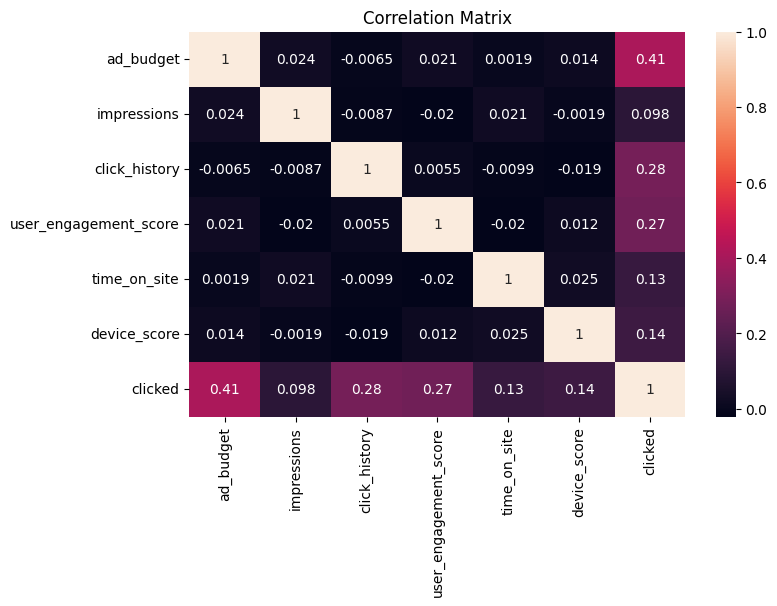

In [18]:
corr_df = df.corr()

plt.figure(figsize = (8,5))

sns.heatmap(corr_df, annot = True)

plt.title('Correlation Matrix')

plt.show();

In [19]:
click_count = df['clicked'].value_counts(normalize = True)

print(f"df shows {click_count[0]:.2%} data as 'Not Clicked' while {click_count[1]:.2%} data as 'Clicked'.")

df shows 88.32% data as 'Not Clicked' while 11.68% data as 'Clicked'.


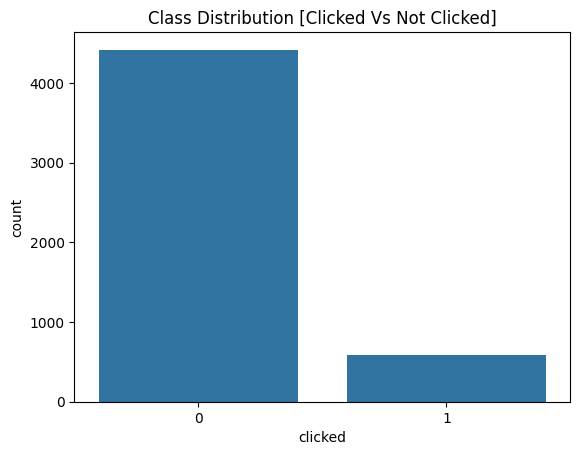

In [20]:
sns.countplot(x = 'clicked', data = df)

plt.title('Class Distribution [Clicked Vs Not Clicked]')

plt.show();

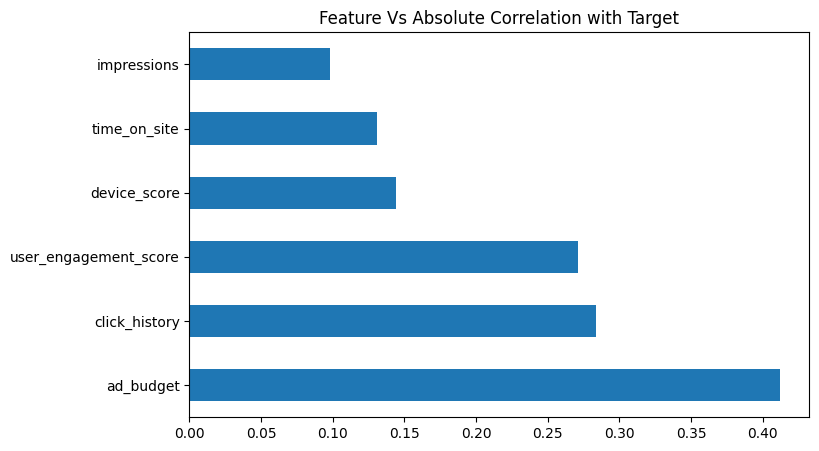

In [21]:
# Feature correlation (absolute correlation with target)

corr_clicked = df.corr(numeric_only = True)['clicked'].drop('clicked')

plt.figure(figsize = (8,5))

corr_clicked.abs().sort_values(ascending = False).plot(kind = 'barh')

plt.title('Feature Vs Absolute Correlation with Target')
plt.show();

### 3. TRAIN / TEST SPLIT (STRATIFIED)

In [22]:
X = df.drop('clicked', axis = 1)

y = df['clicked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 24,
    stratify = y
    # stratify = y ensures that training and testing sets have the exact same percentage of clicks as the original dataset
)

In [23]:
print(f'The train_test_split share comes to {X_train.shape} for X_train and {y_train.shape} for y_train, while {X_test.shape} for X_test and {y_test.shape} for y_test.')

The train_test_split share comes to (4000, 6) for X_train and (4000,) for y_train, while (1000, 6) for X_test and (1000,) for y_test.


In [24]:
print(f'y_train', y_train.value_counts(normalize = True))
print('\n')
print(f'y_test', y_test.value_counts(normalize = True))

y_train clicked
0    0.88325
1    0.11675
Name: proportion, dtype: float64


y_test clicked
0    0.883
1    0.117
Name: proportion, dtype: float64


### 4. BASELINE MODEL

A **DummyClassifier** is a "smart-less" tool used to establish a baseline benchmark for this machine learning project. It does not look at features (ad_budget, impressions, etc.) at all. Instead, it makes predictions using incredibly simple, hardcoded rules.

strategy = 'most_frequent', this classifier will look at training data, find the label that appears most often, and guess that exact label for every single row in the test set. Since _Did not click_ appears approx. 88.3% of the time, DummyClassifier will use this as its strategy classifier.

In [25]:
baseline = DummyClassifier(strategy = 'most_frequent')

baseline.fit(X_train, y_train)

base_pred = baseline.predict(X_test)

print('Baseline Accuracy Score:', accuracy_score(y_test, base_pred))

Baseline Accuracy Score: 0.883


### 5. LOGISTIC REGRESSION PIPELINE

**Logistic Regression** a model used to predict the probability of an outcome, unlike Linear Regression which predicts continuous numerical values. Logistic regression utilises the sigmoid function to calculate probability and employs log loss as its loss function.

In [26]:
logr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter = 1000))
])

logr_pipe.fit(X_train, y_train)

logr_pred = logr_pipe.predict(X_test)

logr_proba = logr_pipe.predict_proba(X_test)[:, 1]

### 6. CLASSIFICATION METRICS

**Accuracy** means  - Out of all the observations in dataset, how correctly did the model predicted whether user clicked or not.

**Precision** means - When model flags a user as 'clicked' how many times is this prediction correct.

**Recall** means - Out of all the users who actually clicked, how many users did the model accurately found.

**F1** means - F1 Score is the harmonic average of _Precision_ and _Recall_.

In [27]:
print('LogR Accuracy Score:', accuracy_score(y_test, logr_pred))
print('LogR Precision Score:', np.round(precision_score(y_test, logr_pred), 4))
print('LogR Recall Score:', np.round(recall_score(y_test, logr_pred), 4))
print('LogR F1 Score:', np.round(f1_score(y_test, logr_pred), 4))

LogR Accuracy Score: 0.985
LogR Precision Score: 0.9474
LogR Recall Score: 0.9231
LogR F1 Score: 0.9351


In [28]:
print('\nClassification Report:\n')
print(classification_report(y_test, logr_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       883
           1       0.95      0.92      0.94       117

    accuracy                           0.98      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.98      0.98      0.98      1000



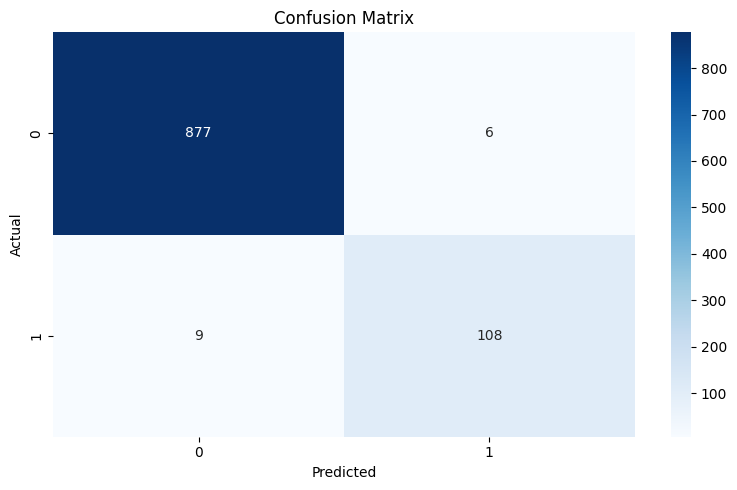

In [29]:
cm = confusion_matrix(y_test, logr_pred)

plt.figure(figsize = (8,5))

sns.heatmap(cm, annot = True, cmap = 'Blues', 
            fmt = 'd')
            # fmt = 'd' converts format to decimal instead of default scientific figure in matrix

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show();

### 7. ROC CURVE + AUC

An ROC Curve stands for **Receiver Operating Characteristic** curve.

It is a graph that displays how well the binary classification model can separate the two classes (clicked vs. not clicked) across every single possible probability threshold.

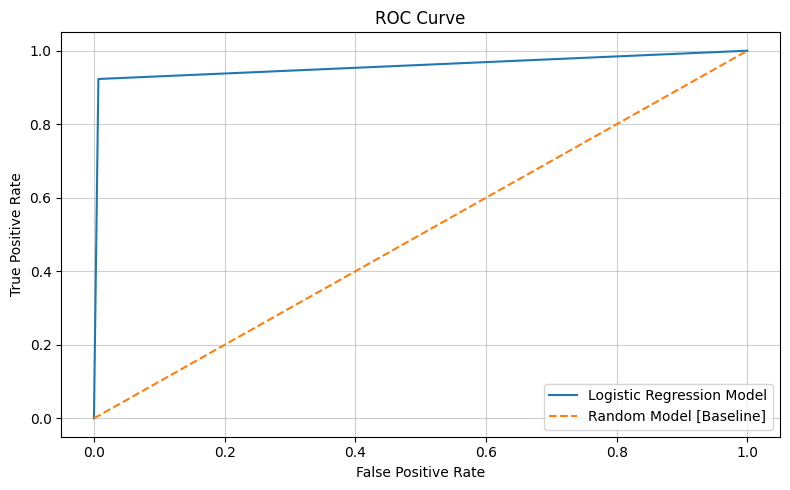

In [30]:
fpr, tpr, _ = roc_curve(y_test, logr_pred)

# fpr - false positive rate, x-axis data
# tpr - true positive rate, y-axis data
# _ - this array lists all the unique probability thresholds Python tested to build the graph (e.g., 0.99, 0.95, 0.50, 0.10) 
# The underscore (_) is a Python convention used to drop the variable since only x,y axis are needed for plotting

plt.figure(figsize = (8,5))

plt.plot(fpr, tpr, label = 'Logistic Regression Model')
plt.plot([0,1], [0,1], linestyle = '--', label = 'Random Model [Baseline]')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha = 0.6)

plt.tight_layout()
plt.show();

AUC Score stands for **Area Under the Curve**. It compresses entire ROC Curve graph into a single, clean number between 0.5 and 1.0.

An AUC of 0.9581 means that roughly 96% of the time, the model will correctly rank the true clicker higher than the non-clicker.

In [31]:
print('ROC AUC Score:', np.round(roc_auc_score(y_test, logr_pred), 4))

ROC AUC Score: 0.9581


### 8. PRECISION-RECALL CURVE

While the ROC Curve gives an overall report card on Logistic Regression model, the **Precision-Recall (PR) Curve** is specifically designed to show the exact trade-off between false alarm rate and missed target rate.

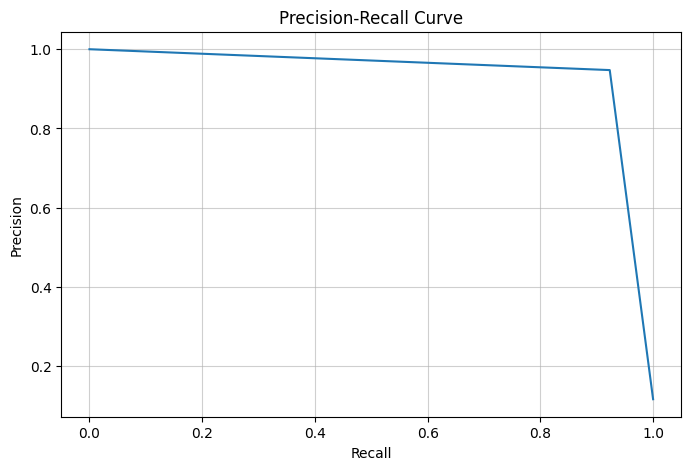

In [32]:
precision, recall, _ = precision_recall_curve(y_test, logr_pred)

plt.figure(figsize = (8,5))

plt.plot(recall, precision)

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.grid(alpha = 0.6)
plt.show();

### 9. Logistic Regression Coefficients

LRC represent the importance weights (coefficients) that Logistic Regression model assigned to each feature after looking at dataset.

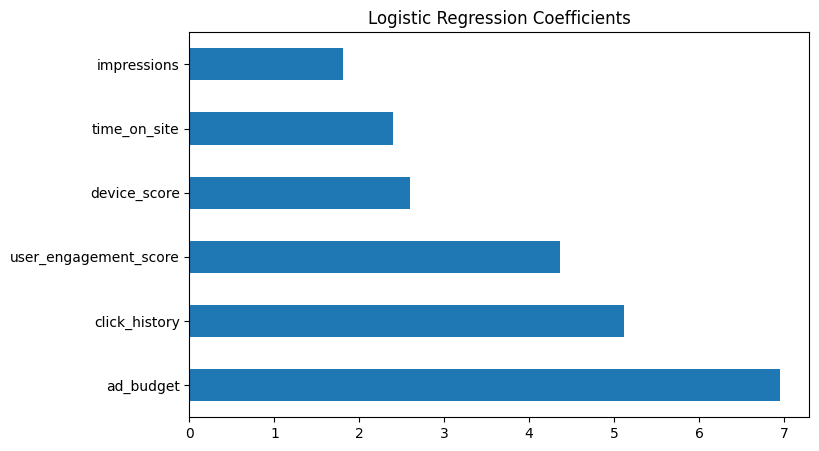

In [33]:
lr_model = logr_pipe.named_steps['model']

coef_lr = pd.Series(lr_model.coef_[0], index = X.columns)

plt.figure(figsize = (8,5))

coef_lr.sort_values(ascending = False).plot(kind = 'barh')

plt.title('Logistic Regression Coefficients')
plt.show();

### 10. CROSS VALIDATION (MODEL ROBUSTNESS)

In [34]:
cv_scores = cross_val_score(logr_pipe, X, y, cv = 5, scoring = 'accuracy')

print('CV Mean Accuracy:', cv_scores.mean())
print('CV Std:', cv_scores.std())

CV Mean Accuracy: 0.9868
CV Std: 0.002039607805437116


### 11. LOGISTIC REGRESSION CV + L1/L2 EXPLORATION

In [35]:
logrcv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(
        Cs = 10,
        # generate 10 mathematically spaced candidate values for regularisation strength. 
        # In Logistic Regression, (C) is the inverse of Alpha. A smaller (C) means a stronger penalty and vise-versa.
        penalty = 'l2',
        # used Ridge Regularisation (L2) to keep feature coefficients small and stable
        solver = 'lbfgs',
        # optimisation algorithm used to solve the logistic math equations
        max_iter = 1000,
        # expands the iteration step limit to 1000
        cv = 5
        # splits training data into 5 folds
    ))
])

logrcv_pipe.fit(X_train, y_train)

# View the optimal C value selected by the algorithm

optimal_C = logrcv_pipe.named_steps['model'].C_[0]

print('The mathematically optimal C value chosen is:', np.round(optimal_C, 4))

The mathematically optimal C value chosen is: 166.8101


#### Logistic Regression Pipeline with optimal C value

In [36]:
results = []

# Comparing l1 and l2 penalties using the 'liblinear' solver

for penalties in ['l1', 'l2']:
    logrC_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            penalty = penalties,
            C = optimal_C,
            solver = 'liblinear',
            # classic solver that supports both l1 and l2
            max_iter = 1000
        ))
    ])

    cvC_scores = cross_val_score(logrC_pipe, X_train, y_train, cv = 5, scoring = 'accuracy')

    results.append([penalties.upper(), cvC_scores.mean()])

pd.DataFrame(results, columns  = ['Penalty', 'CV Accuracy'])

,Penalty,CV Accuracy
0,L1,0.989
1,L2,0.989


**Classification Tuning Conclusion**:

Performance: The model achieved an outstanding cross-validation accuracy of 98.9%.

Penalty Insight: Both L1 (Lasso) and L2 (Ridge) penalties produced identical accuracy metrics. This indicates that dataset features are exceptionally clean and well-separated.

Model Selection: Since accuracy is tied, L1 (Lasso) is the preferred choice. Lasso will drive non-essential or redundant features completely to zero, making the final deployment lighter, faster, and easier to manage in production.

In [37]:
# Training the final winning L1 model on the training set

logrl1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty = 'l1',
        C = optimal_C,
        solver = 'liblinear',
        max_iter = 1000
    ))
])

logrl1_pipe.fit(X_train, y_train)

logrl1_pred = logrl1_pipe.predict(X_test)

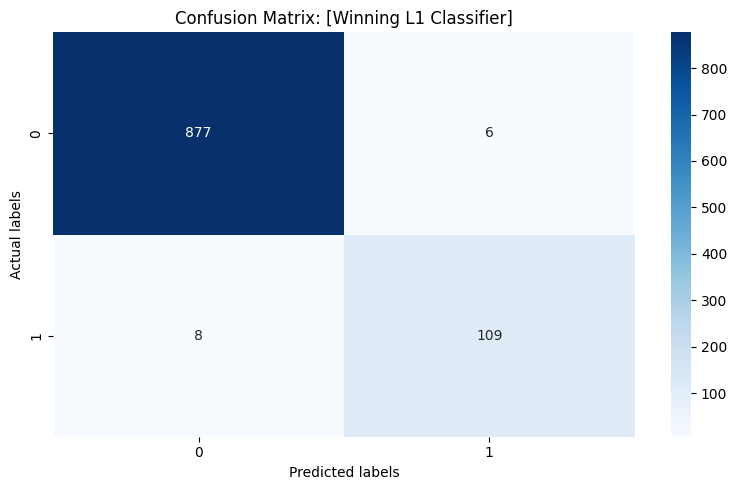

In [38]:
# Plotting Confusion Matrix

cm_l1 = confusion_matrix(y_test, logrl1_pred)

plt.figure(figsize = (8,5))

sns.heatmap(cm_l1, annot = True, cmap = 'Blues', fmt = 'd')

plt.title('Confusion Matrix: [Winning L1 Classifier]')
plt.ylabel('Actual labels')
plt.xlabel('Predicted labels')

plt.tight_layout()
plt.show();